# Robust Classification Under Noisy Labels — Flowers Dataset

**CS 484 Final Project**

Kevin Cui kevin.cui@uwaterloo.ca | Jessica Gao jessica.gao@uwaterloo.ca

## Abstract



## Team contributions
* Jessica Gao jessica.gao@uwaterloo.ca
    * built the logistic regression, GMM reweight, and label smoothing methods
    * developed the training and testing pipeline to run experiments
    * wrote report sections for code libraries, dataset, prediction methods, and final plots
* Kevin Cui kevin.cui@uwaterloo.ca
    * developed the human annotation tool
    * implemented different synthetic noise methods
    * built the confident learning, GCE, and SCE methods
    * wrote report sections for abstract, noise models, and results 

## Pipeline overview

| Phase | What happens |
|---|---|
| **1 — Feature extraction** | Load flower images → DINO ViT-S/16 → cache 384-dim embeddings |
| **2 — Noise infrastructure** | Apply uniform / asymmetric / instance-dependent / human noise |
| **3 — Methods** | 8 noise-robust classifiers with a consistent `fit` / `predict` interface |
| **4A — Synthetic sweep** | Grid over 3 noise types × 6 noise rates × 3 seeds × 8 methods |
| **4B — Real data** | Evaluate on human annotations from the Flask annotation tool |
| **4C — Real data subset** | Evaluate on the subset of 500 human annotations|
| **5 — Figures** | 7 publication-ready plots from the saved JSON results |

**Dataset:** 4 317 Flowers images, 5 classes (daisy · dandelion · rose · sunflower · tulip), fixed 15 % validation split that is *never* corrupted.

---
## Setup & imports

In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

In [5]:
import sys, json, time, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

# ROOT  = directory containing notebook.ipynb  (Noisy-Label-Classifier/)
# MYLIBS = mylibs/ subfolder where all code and data live
ROOT   = Path().resolve()
MYLIBS = ROOT / 'mylibs'

# Add mylibs/ to path so noise/, methods/, experiments/, visualize/, dataset.py
# are all importable without any prefix.
if str(MYLIBS) not in sys.path:
    sys.path.insert(0, str(MYLIBS))

print(f"Project root : {ROOT}")
print(f"mylibs/      : {MYLIBS}")
print(f"Python       : {sys.version.split()[0]}")

import torch
print(f"PyTorch      : {torch.__version__}")
print(f"CUDA         : {torch.cuda.is_available()}  "
      f"({'GPU: ' + torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'})")

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

Project root : C:\Users\Kevin Cui\Desktop\School\Winter 2026\CS 484\Final Project\Noisy-Label-Classifier
mylibs/      : C:\Users\Kevin Cui\Desktop\School\Winter 2026\CS 484\Final Project\Noisy-Label-Classifier\mylibs
Python       : 3.13.11
PyTorch      : 2.6.0+cu124
CUDA         : True  (GPU: NVIDIA GeForce RTX 3060 Laptop GPU)


---
## Phase 1 — Feature Extraction

Run **once**. Downloads DINO from torch hub and extracts 384-dim embeddings for all 4 317 flower images.  
Saves `features.npy`, `labels.npy`, `image_paths.npy`, `val_indices.npy` to `mylibs/`.

Skip this cell if those files already exist.

In [6]:
FEATURES_FILE = MYLIBS / 'features.npy'

if FEATURES_FILE.exists():
    print("features.npy already exists — skipping extraction.")
    print("Delete mylibs/features.npy and re-run this cell to re-extract.")
else:
    print("Extracting DINO features (this takes a few minutes) …")
    from extract_features import extract_dino_features
    extract_dino_features()

features.npy already exists — skipping extraction.
Delete mylibs/features.npy and re-run this cell to re-extract.


In [7]:
# Load cached data — used by every subsequent cell
from dataset import load_data, CLASSES

features, labels, image_paths, train_idx, val_idx = load_data(MYLIBS)

train_features = features[train_idx]
train_labels   = labels[train_idx]
val_features   = features[val_idx]
val_labels     = labels[val_idx]

print(f"Total samples  : {len(labels)}")
print(f"Train / Val    : {len(train_idx)} / {len(val_idx)}")
print(f"Feature dim    : {features.shape[1]}")
print(f"Classes        : {CLASSES}")
print()

# Class distribution
for i, cls in enumerate(CLASSES):
    n_tr = (train_labels == i).sum()
    n_va = (val_labels   == i).sum()
    print(f"  {cls:12s}  train={n_tr:4d}  val={n_va:3d}")

Total samples  : 4317
Train / Val    : 3673 / 644
Feature dim    : 384
Classes        : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

  daisy         train= 650  val=114
  dandelion     train= 895  val=157
  rose          train= 667  val=117
  sunflower     train= 624  val=109
  tulip         train= 837  val=147


---
## Phase 2 — Noise Infrastructure

Four noise types available via the `apply_noise()` factory:

| Type | Description |
|---|---|
| `uniform` | Every label flips to a random wrong class with probability *p* |
| `asymmetric` | Labels only flip within confusable pairs (rose↔tulip, daisy↔sunflower, dandelion→daisy) |
| `instance` | Samples far from their class centroid are mislabeled at higher rates |
| `human` | Labels replaced by human annotations from the Flask annotation tool |

In [8]:
from noise.factory import apply_noise

NOISE_RATE = 0.3

demos = {
    'uniform':    apply_noise(train_features, train_labels, 'uniform',    NOISE_RATE),
    'asymmetric': apply_noise(train_features, train_labels, 'asymmetric', NOISE_RATE),
    'instance':   apply_noise(train_features, train_labels, 'instance',   NOISE_RATE),
}

print(f"Noise demonstrations at requested rate = {NOISE_RATE}\n")
print(f"{'Type':16s}  {'Actual rate':>12s}  {'Flipped':>8s}")
print("-" * 42)
for name, noisy in demos.items():
    actual = (noisy != train_labels).mean()
    n_flip = (noisy != train_labels).sum()
    print(f"{name:16s}  {actual:12.3f}  {n_flip:8d}")

Noise demonstrations at requested rate = 0.3

Type               Actual rate   Flipped
------------------------------------------
uniform                  0.303      1112
asymmetric               0.233       854
instance                 0.200       735


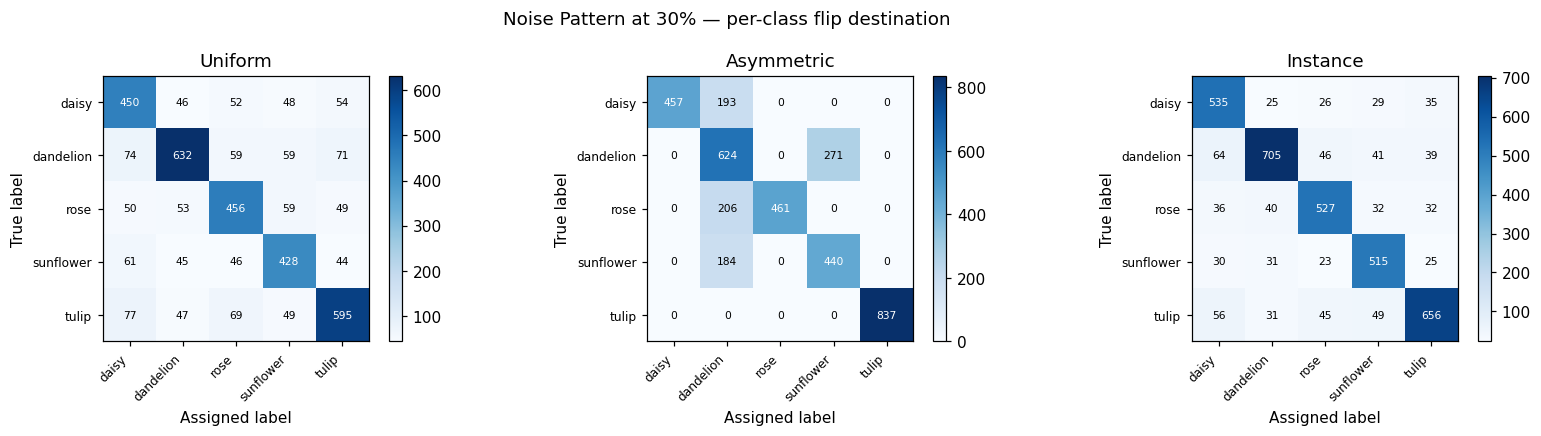

In [9]:
# Visualise which class pairs are affected by each noise type
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Noise Pattern at {int(NOISE_RATE*100)}% — per-class flip destination', fontsize=12)

for ax, (name, noisy) in zip(axes, demos.items()):
    matrix = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)
    for t, n in zip(train_labels, noisy):
        matrix[t, n] += 1

    im = ax.imshow(matrix, cmap='Blues')
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES, fontsize=8)
    ax.set_xlabel('Assigned label'); ax.set_ylabel('True label')
    ax.set_title(name.capitalize())
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            ax.text(j, i, str(matrix[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if matrix[i,j] > matrix.max()*0.5 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

### Human annotation noise
Run the Flask annotation tool first (`python run_pipeline.py --phase annotate`), then execute the cell below to see the effective noise rate from the collected labels.

In [10]:
import csv
from collections import Counter

ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'

if not ANNOTATIONS_CSV.exists() or ANNOTATIONS_CSV.stat().st_size < 50:
    print("manual_annotations.csv is empty — run the annotation tool first.")
    print("  python mylibs/run_pipeline.py --phase annotate")
else:
    human_noisy = apply_noise(
        train_features, labels, 'human',
        image_paths=image_paths,
        train_idx=train_idx,
        annotations_csv=str(ANNOTATIONS_CSV),
    )
    actual_rate = (human_noisy != train_labels).mean()
    n_annotated = sum(1 for r in csv.DictReader(open(ANNOTATIONS_CSV))
                      if int(r['label']) != -1)

    print(f"Annotations collected : {n_annotated}")
    print(f"Effective noise rate  : {actual_rate:.3f}")

    # Per-class breakdown
    print("\nPer-class error rate (annotated samples only):")
    for i, cls in enumerate(CLASSES):
        mask = train_labels == i
        n    = mask.sum()
        if n == 0: continue
        wrong = (human_noisy[mask] != train_labels[mask]).sum()
        print(f"  {cls:12s}  {wrong}/{n}  ({wrong/n:.1%})")

[human_noise] Applied 433/3673 annotations (effective noise rate: 0.016)
Annotations collected : 500
Effective noise rate  : 0.016

Per-class error rate (annotated samples only):
  daisy         9/650  (1.4%)
  dandelion     5/895  (0.6%)
  rose          6/667  (0.9%)
  sunflower     14/624  (2.2%)
  tulip         26/837  (3.1%)


---
## Phase 3 — Methods

Six methods all share `fit(features, noisy_labels)` / `predict(features)`:

| Method | Core idea |
|---|---|
| `BaselineCE` | Standard cross-entropy — lower bound |
| `LabelSmoothing` | Spread ε probability mass to prevent overconfidence |
| `SCE` | Symmetric CE: add a reverse-CE term for robustness |
| `GCE` | Generalised CE: q-loss interpolates between CE (q→1) and MAE (q→0) |
| `GMMReweight` | Fit 2-component GMM to losses; upweight clean-component samples |
| `ConfidentLearning` | OOF probs → flag likely mislabelled → prune → retrain |

The cell below runs a **quick single-condition sanity check** (30% uniform noise) so you can verify all methods work before launching the full sweep.

In [11]:
from methods import (BaselineCE, LabelSmoothing, SCE, GCE,
                     GMMReweight, ConfidentLearning)

# Quick sanity-check: 30% uniform noise, 40 epochs
QUICK_EPOCHS = 40
QUICK_NOISE  = 0.3

noisy_quick = apply_noise(train_features, train_labels, 'uniform', QUICK_NOISE)

kw = dict(val_features=val_features, val_labels=val_labels, epochs=QUICK_EPOCHS)
sanity_methods = [
    BaselineCE(**kw),
    LabelSmoothing(**kw),
    SCE(**kw),
    GCE(**kw),
    GMMReweight(warmup_epochs=12, total_epochs=QUICK_EPOCHS, **kw),
    ConfidentLearning(warmup_epochs=QUICK_EPOCHS // 2, total_epochs=QUICK_EPOCHS, **kw),
]

print(f"Sanity check — uniform {int(QUICK_NOISE*100)}% noise, {QUICK_EPOCHS} epochs\n")
print(f"{'Method':20s}  {'Val Acc':>8s}")
print("-" * 32)
for m in sanity_methods:
    t0 = time.time()
    m.fit(train_features, noisy_quick)
    acc  = m.evaluate(val_features, val_labels)
    elapsed = time.time() - t0
    print(f"{m.name:20s}  {acc:8.4f}  ({elapsed:.1f}s)")

Sanity check — uniform 30% noise, 40 epochs

Method                 Val Acc
--------------------------------
BaselineCE              0.6972  (7.8s)
LabelSmoothing          0.6693  (5.4s)
SCE                     0.8339  (5.8s)
GCE                     0.9006  (5.6s)
GMMReweight             0.7935  (11.9s)
ConfidentLearning       0.8121  (11.8s)


---
## Phase 4A — Synthetic Sweep

Full grid: **3 noise types × 6 noise rates × 3 seeds × 8 methods = 432 training runs**.

Results are saved to `results/synthetic_results.json` and `results/synthetic_aux.json`.  
**Re-running this cell will overwrite existing results.**

> ⏱ Estimated time: ~20 min on GPU, ~3–5 hours on CPU.

In [12]:
from experiments.synthetic_sweep import run as run_synthetic_sweep

run_synthetic_sweep()


[1/54] type=uniform  rate=0.0  seed=0  (0.0 min elapsed)
    BaselineCE ... acc=0.9115
    LabelSmoothing ... acc=0.8820
    SCE ... acc=0.9193
    GCE ... acc=0.9239
    GMMReweight ... acc=0.9130
    ConfidentLearning ... acc=0.9130

[2/54] type=uniform  rate=0.0  seed=1  (2.0 min elapsed)
    BaselineCE ... acc=0.9177
    LabelSmoothing ... acc=0.8556
    SCE ... acc=0.9208
    GCE ... acc=0.9053
    GMMReweight ... acc=0.8991
    ConfidentLearning ... acc=0.9193

[3/54] type=uniform  rate=0.0  seed=2  (4.0 min elapsed)
    BaselineCE ... acc=0.8991
    LabelSmoothing ... acc=0.8634
    SCE ... acc=0.9177
    GCE ... acc=0.9146
    GMMReweight ... acc=0.9130
    ConfidentLearning ... acc=0.9177

[4/54] type=uniform  rate=0.1  seed=0  (5.7 min elapsed)
    BaselineCE ... acc=0.7764
    LabelSmoothing ... acc=0.8028
    SCE ... acc=0.8540
    GCE ... acc=0.8991
    GMMReweight ... acc=0.8820
    ConfidentLearning ... acc=0.8727

[5/54] type=uniform  rate=0.1  seed=1  (7.3 min elapsed

In [ ]:
# Quick summary table of synthetic results
SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

if not SYNTHETIC_FILE.exists():
    print("synthetic_results.json not found — run the sweep above first.")
else:
    with open(SYNTHETIC_FILE) as f:
        syn_results = json.load(f)

    NOISE_TYPES  = ['uniform', 'asymmetric', 'instance']
    NOISE_RATES  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                    'GMMReweight', 'ConfidentLearning']

    for noise_type in NOISE_TYPES:
        print(f"\n{'='*70}")
        print(f"  Noise type: {noise_type}")
        print(f"{'='*70}")
        header = f"{'Method':20s}" + "".join(f"  nr={nr:.1f}" for nr in NOISE_RATES)
        print(header)
        print("-" * len(header))
        for m in METHOD_ORDER:
            row = f"{m:20s}"
            for nr in NOISE_RATES:
                accs = syn_results.get(noise_type, {}).get(str(float(nr)), {}).get(m, [])
                if accs:
                    row += f"  {np.mean(accs):.3f}"
                else:
                    row += "    — "
            print(row)


  Noise type: uniform
Method                nr=0.0  nr=0.1  nr=0.2  nr=0.3  nr=0.4  nr=0.5
--------------------------------------------------------------------
BaselineCE            0.909  0.784  0.736  0.639  0.558  0.487
LabelSmoothing        0.867  0.795  0.657  0.673  0.531  0.499
SCE                   0.919  0.859  0.848  0.796  0.731  0.651
GCE                   0.915  0.905  0.902  0.891  0.866  0.853
GMMReweight           0.908  0.860  0.822  0.732  0.627  0.527
ConfidentLearning     0.917  0.865  0.838  0.783  0.740  0.704

  Noise type: asymmetric
Method                nr=0.0  nr=0.1  nr=0.2  nr=0.3  nr=0.4  nr=0.5
--------------------------------------------------------------------
BaselineCE            0.906  0.797  0.718  0.659  0.607  0.570
LabelSmoothing        0.870  0.832  0.717  0.686  0.608  0.532
SCE                   0.909  0.874  0.847  0.742  0.681  0.571
GCE                   0.909  0.907  0.899  0.765  0.752  0.465
GMMReweight           0.910  0.878  0.837  0.

: 

---
## Phase 4B — Real Data Experiment

Evaluates all methods on four label sets:

| Label set | Description |
|---|---|
| `clean` | Original ground-truth labels (upper bound) |
| `human` | Human annotations from the Flask annotation tool |
| `uniform_30` | 30% uniform noise (synthetic reference) |
| `asymmetric_30` | 30% asymmetric noise (synthetic reference) |

> Run the annotation tool before this phase to populate `manual_annotations.csv`.

In [14]:
from experiments.real_data import run as run_real_experiment

run_real_experiment()

[human_noise] Applied 433/3673 annotations (effective noise rate: 0.016)
  clean: noise_rate = 0.000
  human: noise_rate = 0.016
  uniform_30: noise_rate = 0.303
  asymmetric_30: noise_rate = 0.233
[1/24] clean / BaselineCE ... acc=0.9099
[2/24] clean / LabelSmoothing ... acc=0.8556
[3/24] clean / SCE ... acc=0.9146
[4/24] clean / GCE ... acc=0.9193
[5/24] clean / GMMReweight ... acc=0.8991
[6/24] clean / ConfidentLearning ... acc=0.9161
[7/24] human / BaselineCE ... acc=0.8758
[8/24] human / LabelSmoothing ... acc=0.8711
[9/24] human / SCE ... acc=0.9161
[10/24] human / GCE ... acc=0.9161
[11/24] human / GMMReweight ... acc=0.8975
[12/24] human / ConfidentLearning ... acc=0.9099
[13/24] uniform_30 / BaselineCE ... acc=0.6910
[14/24] uniform_30 / LabelSmoothing ... acc=0.6661
[15/24] uniform_30 / SCE ... acc=0.8168
[16/24] uniform_30 / GCE ... acc=0.9022
[17/24] uniform_30 / GMMReweight ... acc=0.8370
[18/24] uniform_30 / ConfidentLearning ... acc=0.7826
[19/24] asymmetric_30 / Baselin

In [15]:
# Summary table for real data results
REAL_FILE = MYLIBS / 'results' / 'real_results.json'

if not REAL_FILE.exists():
    print("real_results.json not found — run the experiment above first.")
else:
    with open(REAL_FILE) as f:
        real_data = json.load(f)

    results    = real_data['results']
    noise_info = real_data['noise_rates']
    label_sets = real_data['label_sets']

    print(f"{'Method':20s}", end='')
    for ls in label_sets:
        nr = noise_info.get(ls, 0)
        print(f"  {ls[:12]:>14s}", end='')
    print()
    print(f"{'':20s}", end='')
    for ls in label_sets:
        nr = noise_info.get(ls, 0)
        print(f"  {'(nr='+f'{nr:.2f}'+')':>14s}", end='')
    print()
    print("-" * (20 + 16 * len(label_sets)))

    METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                    'GMMReweight', 'ConfidentLearning']
    for m in METHOD_ORDER:
        print(f"{m:20s}", end='')
        for ls in label_sets:
            acc = results.get(ls, {}).get(m, None)
            print(f"  {acc:14.4f}" if acc is not None else f"  {'—':>14s}", end='')
        print()

Method                         clean           human      uniform_30    asymmetric_3
                           (nr=0.00)       (nr=0.02)       (nr=0.30)       (nr=0.23)
------------------------------------------------------------------------------------
BaselineCE                    0.9099          0.8758          0.6910          0.6335
LabelSmoothing                0.8556          0.8711          0.6661          0.6925
SCE                           0.9146          0.9161          0.8168          0.7764
GCE                           0.9193          0.9161          0.9022          0.8773
GMMReweight                   0.8991          0.8975          0.8370          0.6149
ConfidentLearning             0.9161          0.9099          0.7826          0.7516


---
## Phase 4C — Annotated Subset Only

Train all methods on **only the 500 human-annotated samples** rather than the full 3 673-sample training set.

This isolates the human label noise: the effective noise rate rises from ~1.6% (60 errors diluted across 3 673 samples) to ~12% (60 errors out of 500 annotated samples), making noise-robust methods actually differentiable on real data.

Results saved to `results/annotated_subset_results.json`.

In [ ]:
from noise.human import _load_csv as _load_annotation_csv

_ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'
_RESULTS_DIR     = MYLIBS / 'results'
_RESULTS_DIR.mkdir(exist_ok=True)

if not _ANNOTATIONS_CSV.exists() or _ANNOTATIONS_CSV.stat().st_size < 50:
    print("manual_annotations.csv not found — run annotation tool first.")
else:
    _annotation_map = _load_annotation_csv(str(_ANNOTATIONS_CSV))
    _image_dir      = Path(str(image_paths[train_idx[0]])).parent.parent

    _positions, _human_labels = [], []
    for _pos, _gidx in enumerate(train_idx):
        _abs = Path(str(image_paths[_gidx]))
        try:
            _rel = _abs.relative_to(_image_dir).as_posix()
        except ValueError:
            continue
        if _rel in _annotation_map:
            _positions.append(_pos)
            _human_labels.append(_annotation_map[_rel])

    _positions    = np.array(_positions)
    _human_labels = np.array(_human_labels)

    _sub_features = train_features[_positions]
    _sub_clean    = train_labels[_positions]
    _n_err        = int((_human_labels != _sub_clean).sum())
    _noise_rate   = float((_human_labels != _sub_clean).mean())

    print(f"Annotated subset : {len(_positions)} samples")
    print(f"Noise rate       : {_noise_rate:.3f}  ({_n_err} errors)\n")

    _EPOCHS = 100
    _kw = dict(val_features=val_features, val_labels=val_labels, epochs=_EPOCHS)
    _subset_methods = [
        BaselineCE(**_kw),
        LabelSmoothing(**_kw),
        SCE(**_kw),
        GCE(**_kw),
        GMMReweight(warmup_epochs=30, total_epochs=_EPOCHS, **_kw),
        ConfidentLearning(warmup_epochs=_EPOCHS // 2, total_epochs=_EPOCHS, **_kw),
    ]

    _subset_results = {}
    _t0 = time.time()
    for _i, _m in enumerate(_subset_methods, 1):
        print(f"[{_i}/{len(_subset_methods)}] {_m.name} ...", end='', flush=True)
        _m.fit(_sub_features, _human_labels)
        _acc = _m.evaluate(val_features, val_labels)
        print(f" acc={_acc:.4f}")
        _subset_results[_m.name] = _acc

    with open(_RESULTS_DIR / 'annotated_subset_results.json', 'w') as _f:
        json.dump({
            'results':    _subset_results,
            'n_samples':  int(len(_positions)),
            'noise_rate': _noise_rate,
            'n_errors':   _n_err,
        }, _f, indent=2)

    print(f"\nDone in {(time.time()-_t0)/60:.1f} min")
    print("Saved: results/annotated_subset_results.json")

In [ ]:
# Summary table — annotated subset vs full-training reference
_SUBSET_FILE = MYLIBS / 'results' / 'annotated_subset_results.json'
_REAL_FILE   = MYLIBS / 'results' / 'real_results.json'

if not _SUBSET_FILE.exists():
    print("annotated_subset_results.json not found — run the cell above first.")
else:
    with open(_SUBSET_FILE) as _f:
        _sd = json.load(_f)
    with open(_REAL_FILE) as _f:
        _rd = json.load(_f)

    print(f"Training set : {_sd['n_samples']} annotated samples  |  "
          f"noise rate = {_sd['noise_rate']:.3f}  ({_sd['n_errors']} errors)\n")

    _METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                     'GMMReweight', 'ConfidentLearning']
    _nr = _sd['noise_rate']
    print(f"{'Method':20s}  {'Clean (full)':>12s}  {'Human full (nr=0.02)':>20s}  {'Subset only (nr='+f'{_nr:.2f}'+')':>24s}")
    print("-" * 82)
    for _m in _METHOD_ORDER:
        _c = _rd['results']['clean'].get(_m, float('nan'))
        _h = _rd['results']['human'].get(_m, float('nan'))
        _s = _sd['results'].get(_m, float('nan'))
        print(f"{_m:20s}  {_c:12.4f}  {_h:20.4f}  {_s:24.4f}")

---
## Phase 5 — Figures

All plots read from the saved JSON files — no models are re-trained.

| Figure | Content |
|---|---|
| **Fig 1** | Accuracy vs noise rate — one subplot per noise type |
| **Fig 2** | GMM loss histogram — bimodal clean/noisy distribution |
| **Fig 3** | Transition matrix — CL estimate vs ground truth |
| **Fig 4** | Flagged sample grid — images CL identified as mislabelled |
| **Fig 5** | Noise rate calibration — CL estimated vs true rate |
| **Fig 6** | Learning curves — val accuracy over epochs at 40% uniform noise |
| **Fig 7** | Real data bar chart — human annotations vs synthetic baselines |
| **Fig 8** | Annotated subset bar chart — Clean vs Human-full vs Subset-only per method |
| **Fig 9** | Human noise vs equivalent synthetic noise at comparable noise rates |
| **Fig 10** | Per-class annotation error breakdown — counts and flip-destination heatmap |

### Figure 1 — Accuracy vs. Noise Rate

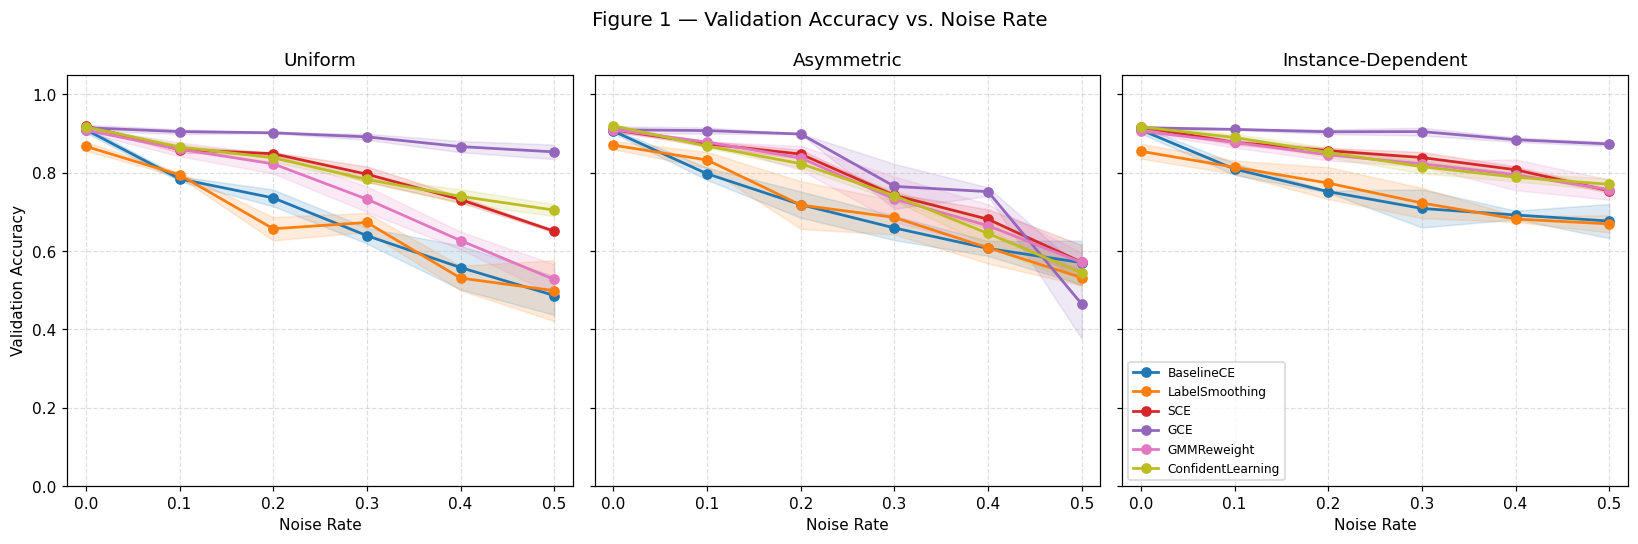

In [16]:
SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

if not SYNTHETIC_FILE.exists():
    print("Run Phase 4A first.")
else:
    with open(SYNTHETIC_FILE) as f:
        syn_results = json.load(f)

    NOISE_TYPES  = ['uniform', 'asymmetric', 'instance']
    NOISE_LABELS = ['Uniform', 'Asymmetric', 'Instance-Dependent']
    NOISE_RATES  = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
    METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                    'GMMReweight', 'ConfidentLearning']
    colors = cm.tab10(np.linspace(0, 0.8, len(METHOD_ORDER)))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    fig.suptitle('Figure 1 — Validation Accuracy vs. Noise Rate', fontsize=13)

    for ax, nt, nl in zip(axes, NOISE_TYPES, NOISE_LABELS):
        nt_data = syn_results.get(nt, {})
        for m_name, color in zip(METHOD_ORDER, colors):
            means, stds = [], []
            for nr in NOISE_RATES:
                accs = nt_data.get(str(float(nr)), {}).get(m_name, [])
                means.append(np.mean(accs) if accs else np.nan)
                stds.append(np.std(accs)  if accs else 0.0)
            means, stds = np.array(means), np.array(stds)
            valid = ~np.isnan(means)
            ax.plot(np.array(NOISE_RATES)[valid], means[valid],
                    label=m_name, color=color, marker='o', linewidth=1.8)
            ax.fill_between(np.array(NOISE_RATES)[valid],
                            (means - stds)[valid], (means + stds)[valid],
                            color=color, alpha=0.15)
        ax.set_title(nl); ax.set_xlabel('Noise Rate')
        ax.set_xticks(NOISE_RATES); ax.set_xlim(-0.02, 0.52)
        ax.set_ylim(0.0, 1.05); ax.grid(True, linestyle='--', alpha=0.4)

    axes[0].set_ylabel('Validation Accuracy')
    axes[-1].legend(loc='lower left', fontsize=8)
    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig1_accuracy_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 2 — GMM Loss Histogram

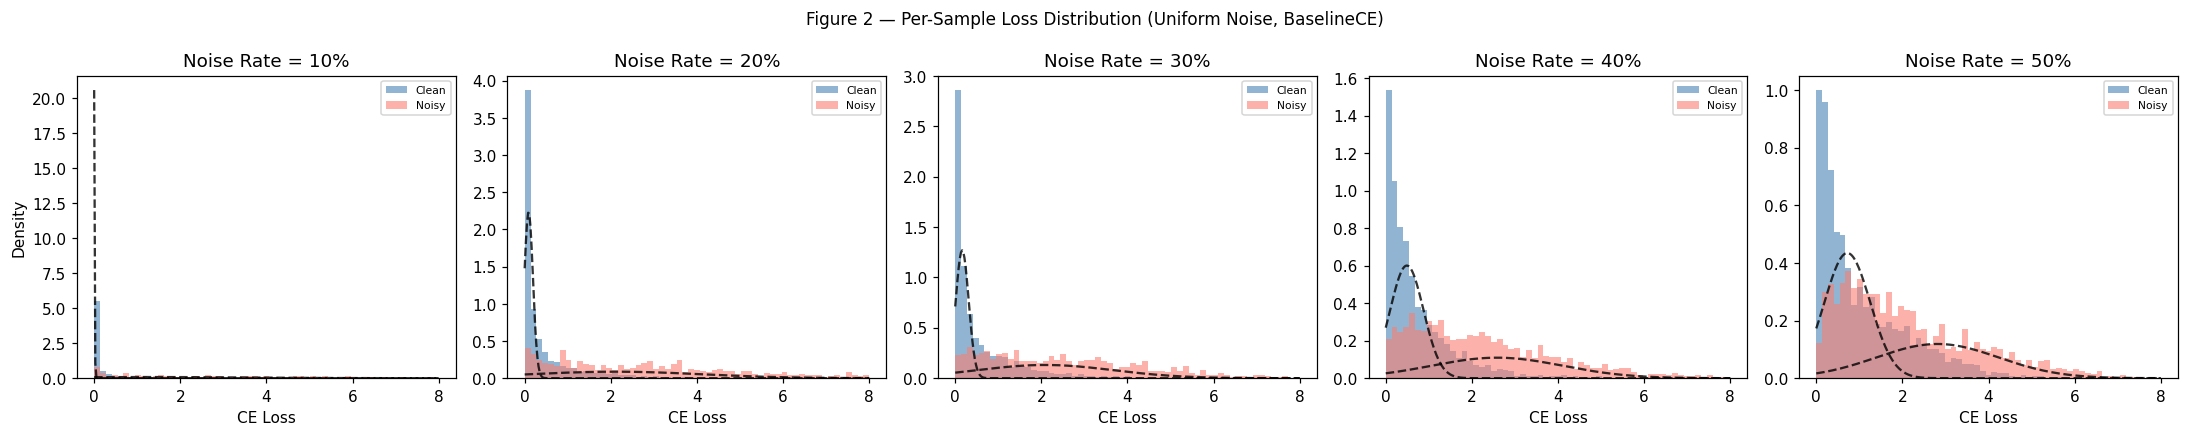

In [17]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm as scipy_norm

AUX_FILE = MYLIBS / 'results' / 'synthetic_aux.json'

if not AUX_FILE.exists():
    print("Run Phase 4A first.")
else:
    with open(AUX_FILE) as f:
        aux = json.load(f)

    HIST_RATES = [0.1, 0.2, 0.3, 0.4, 0.5]
    fig, axes  = plt.subplots(1, len(HIST_RATES), figsize=(4 * len(HIST_RATES), 4))
    fig.suptitle('Figure 2 — Per-Sample Loss Distribution (Uniform Noise, BaselineCE)', fontsize=11)

    for ax, nr in zip(axes, HIST_RATES):
        key    = f"uniform_{nr}_BaselineCE"
        losses = aux.get('losses', {}).get(key)
        if losses is None:
            ax.set_title(f'nr={nr}\n(no data)'); continue

        losses = np.array(losses)
        noisy_tr = apply_noise(train_features, train_labels, 'uniform', nr, seed=0)
        is_noisy = noisy_tr != train_labels

        bins = np.linspace(0, min(losses.max(), 8.0), 60)
        ax.hist(losses[~is_noisy], bins=bins, alpha=0.6, color='steelblue',
                label='Clean', density=True)
        ax.hist(losses[is_noisy],  bins=bins, alpha=0.6, color='salmon',
                label='Noisy', density=True)

        gmm = GaussianMixture(n_components=2, random_state=42).fit(losses.reshape(-1, 1))
        x   = np.linspace(0, min(losses.max(), 8.0), 300)
        for k in range(2):
            mu  = gmm.means_[k, 0]
            sig = np.sqrt(gmm.covariances_[k, 0, 0])
            ax.plot(x, gmm.weights_[k] * scipy_norm.pdf(x, mu, sig),
                    'k--', linewidth=1.5, alpha=0.8)

        ax.set_title(f'Noise Rate = {int(nr*100)}%')
        ax.set_xlabel('CE Loss')
        if ax is axes[0]: ax.set_ylabel('Density')
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig2_loss_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 3 — Transition Matrix Heatmap

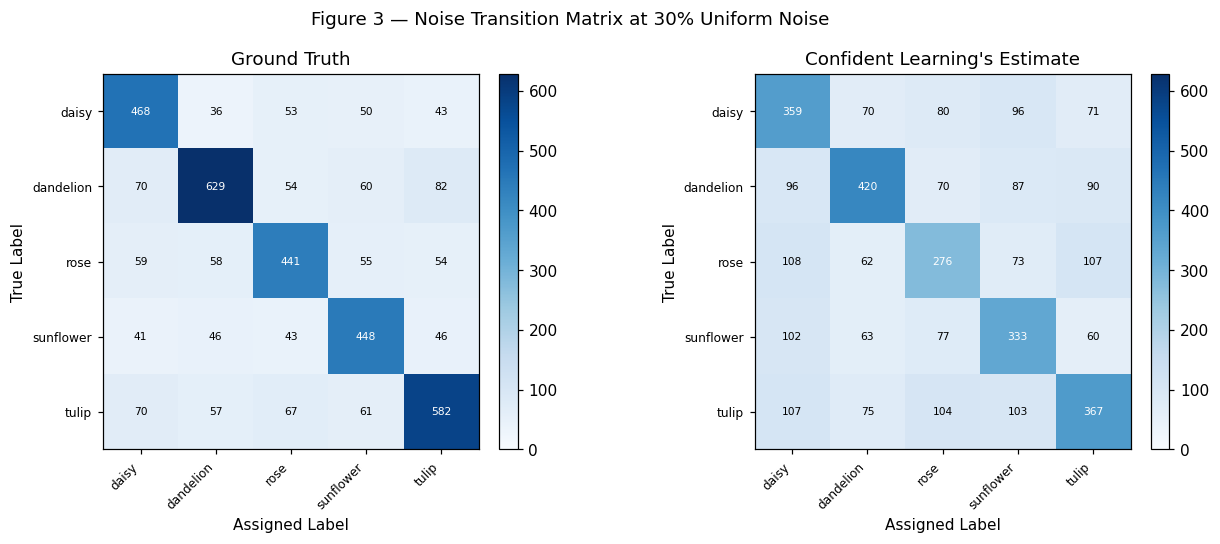

In [18]:
if not AUX_FILE.exists():
    print("Run Phase 4A first.")
else:
    true_mat = aux.get('cl_true_matrix')
    est_mat  = aux.get('cl_count_matrix')

    if true_mat is None or est_mat is None:
        print("Transition matrix data not found — re-run the sweep.")
    else:
        def plot_mat(ax, mat, classes, title, vmax):
            mat = np.array(mat, dtype=float)
            im  = ax.imshow(mat, cmap='Blues', vmin=0, vmax=vmax)
            ax.set_xticks(range(len(classes))); ax.set_yticks(range(len(classes)))
            ax.set_xticklabels(classes, rotation=45, ha='right', fontsize=8)
            ax.set_yticklabels(classes, fontsize=8)
            ax.set_xlabel('Assigned Label'); ax.set_ylabel('True Label')
            ax.set_title(title)
            for i in range(len(classes)):
                for j in range(len(classes)):
                    c = 'white' if mat[i,j] > mat.max()*0.6 else 'black'
                    ax.text(j, i, str(int(mat[i,j])), ha='center', va='center', fontsize=7, color=c)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        vmax = max(np.array(true_mat).max(), np.array(est_mat).max())
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle('Figure 3 — Noise Transition Matrix at 30% Uniform Noise', fontsize=12)
        plot_mat(ax1, true_mat, CLASSES, 'Ground Truth',                vmax)
        plot_mat(ax2, est_mat,  CLASSES, "Confident Learning's Estimate", vmax)
        plt.tight_layout()
        plt.savefig(MYLIBS / 'results' / 'fig3_transition_matrix.png', dpi=150, bbox_inches='tight')
        plt.show()

### Figure 4 — Flagged Sample Grid

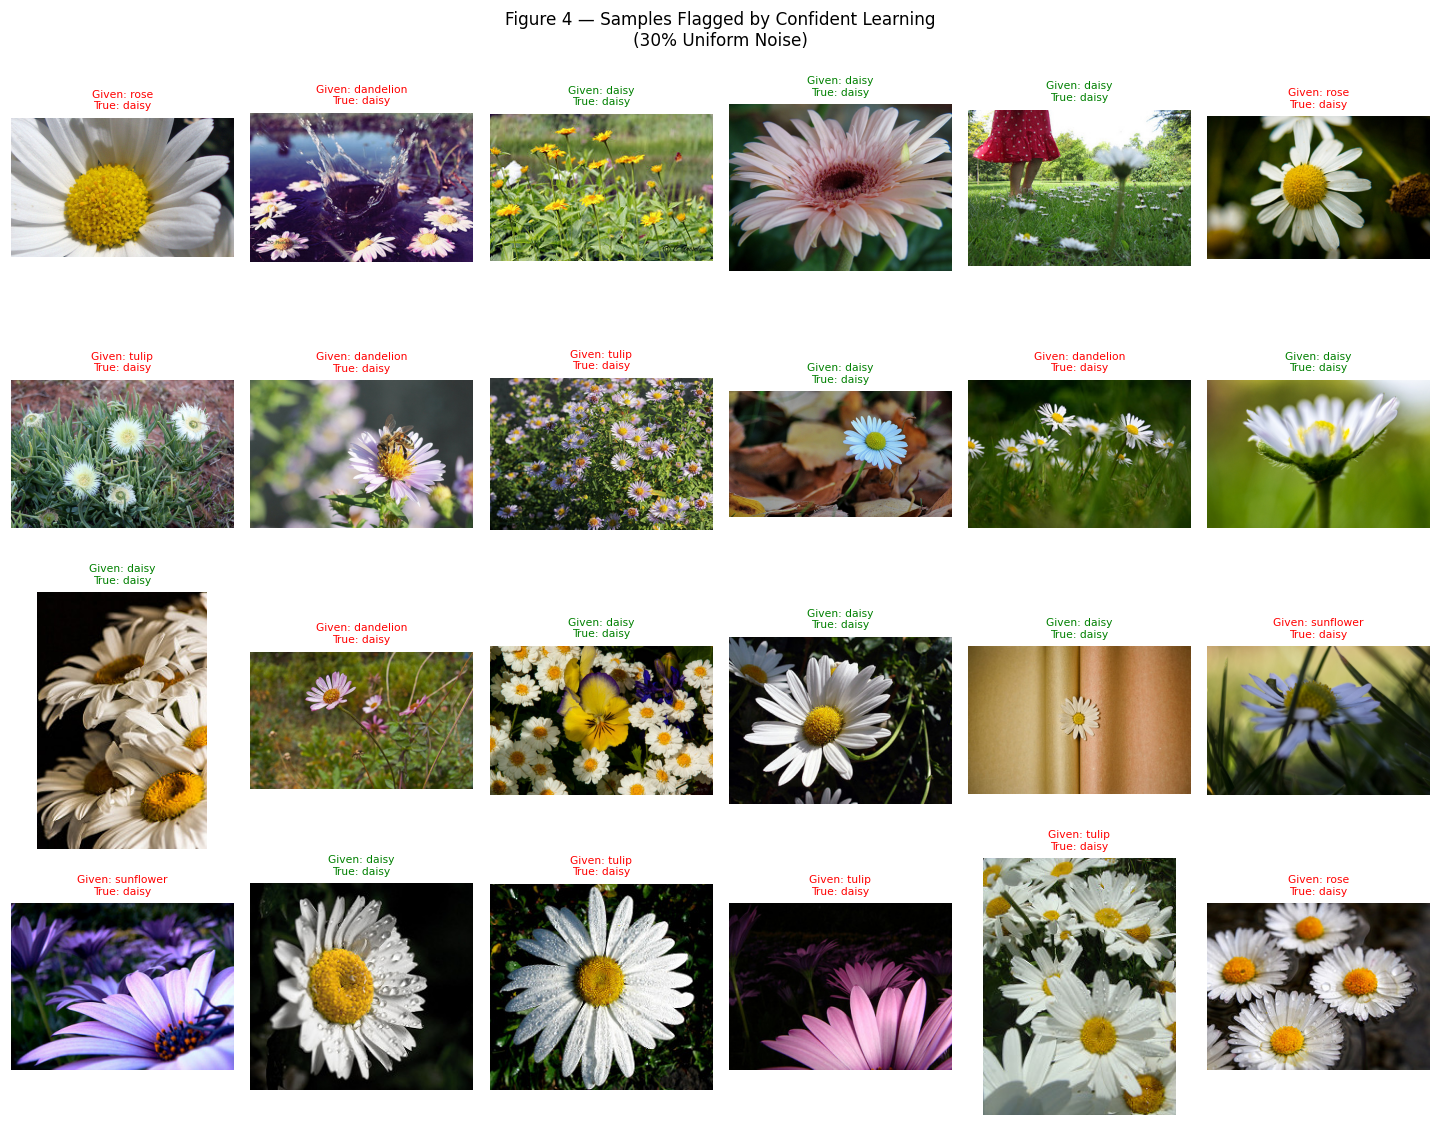

In [19]:
from PIL import Image as PILImage

if not AUX_FILE.exists():
    print("Run Phase 4A first.")
else:
    flagged_global = aux.get('cl_flagged')
    if not flagged_global:
        print("No flagged samples saved — re-run sweep.")
    else:
        flagged = np.array(flagged_global, dtype=np.int64)
        noisy_30 = apply_noise(train_features, train_labels, 'uniform', 0.3, seed=0)

        GRID_ROWS, GRID_COLS = 4, 6
        show_idx = flagged[:GRID_ROWS * GRID_COLS]
        n_show   = len(show_idx)
        rows     = (n_show + GRID_COLS - 1) // GRID_COLS

        fig, axes = plt.subplots(rows, GRID_COLS, figsize=(GRID_COLS * 2.2, rows * 2.6))
        fig.suptitle('Figure 4 — Samples Flagged by Confident Learning\n(30% Uniform Noise)',
                     fontsize=11)
        axes_flat = np.array(axes).ravel()

        for i, train_pos in enumerate(show_idx):
            global_idx = train_idx[train_pos]
            img_path   = str(image_paths[global_idx])
            given_lbl  = CLASSES[noisy_30[train_pos]]
            true_lbl   = CLASSES[train_labels[train_pos]]
            ax = axes_flat[i]
            try:
                ax.imshow(PILImage.open(img_path).convert('RGB'))
            except Exception:
                ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes, ha='center', va='center')
            color = 'red' if given_lbl != true_lbl else 'green'
            ax.set_title(f'Given: {given_lbl}\nTrue: {true_lbl}', fontsize=7, color=color)
            ax.axis('off')

        for j in range(n_show, len(axes_flat)):
            axes_flat[j].axis('off')

        plt.tight_layout()
        plt.savefig(MYLIBS / 'results' / 'fig4_flagged_samples.png', dpi=120, bbox_inches='tight')
        plt.show()

### Figure 5 — Noise Rate Calibration

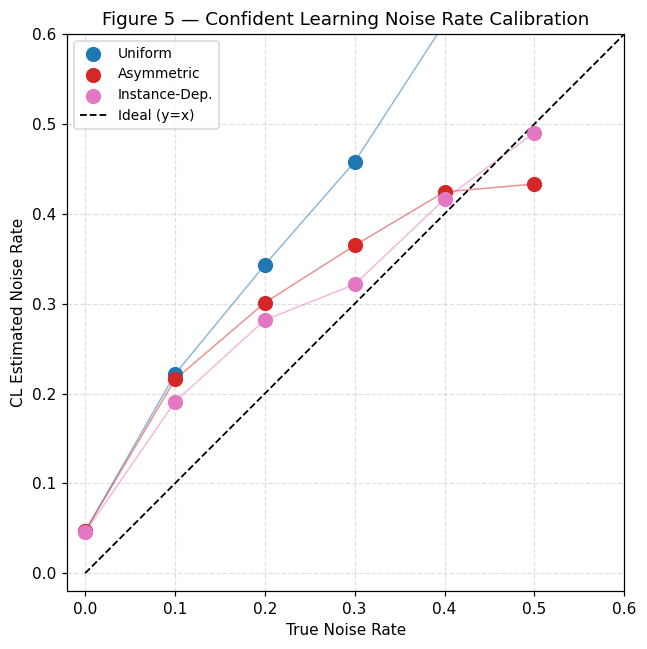

In [20]:
if not AUX_FILE.exists():
    print("Run Phase 4A first.")
else:
    cl_est    = aux.get('cl_noise_est', {})
    nr_stored = aux.get('noise_rates', [0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    nt_list   = aux.get('noise_types', ['uniform', 'asymmetric', 'instance'])
    nt_labels = {'uniform': 'Uniform', 'asymmetric': 'Asymmetric', 'instance': 'Instance-Dep.'}
    colors_cal = cm.tab10(np.linspace(0, 0.6, len(nt_list)))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_title('Figure 5 — Confident Learning Noise Rate Calibration', fontsize=12)

    for nt, color in zip(nt_list, colors_cal):
        true_r, est_r = [], []
        for nr in nr_stored:
            key = f"{nt}_{nr}"
            if key in cl_est:
                true_r.append(nr); est_r.append(cl_est[key])
        if true_r:
            ax.scatter(true_r, est_r, color=color, s=80, zorder=3,
                       label=nt_labels.get(nt, nt))
            ax.plot(true_r, est_r, color=color, linewidth=1, alpha=0.5)

    lim = max(max(nr_stored) + 0.05, 0.6)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Ideal (y=x)', zorder=2)
    ax.set_xlim(-0.02, lim); ax.set_ylim(-0.02, lim)
    ax.set_xlabel('True Noise Rate'); ax.set_ylabel('CL Estimated Noise Rate')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig5_calibration.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 6 — Learning Curves

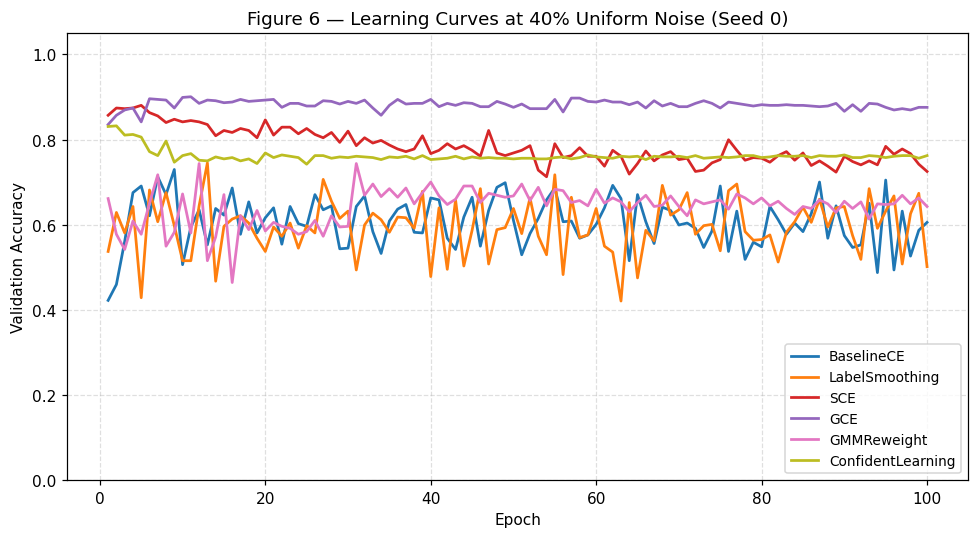

In [21]:
if not AUX_FILE.exists():
    print("Run Phase 4A first.")
else:
    curves = aux.get('epoch_curves', {})
    if not curves:
        print("No epoch curves saved — re-run sweep.")
    else:
        METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                        'GMMReweight', 'ConfidentLearning']
        colors_lc = cm.tab10(np.linspace(0, 0.8, len(METHOD_ORDER)))

        fig, ax = plt.subplots(figsize=(9, 5))
        ax.set_title('Figure 6 — Learning Curves at 40% Uniform Noise (Seed 0)', fontsize=12)

        for m_name, color in zip(METHOD_ORDER, colors_lc):
            if m_name in curves:
                accs = curves[m_name]
                ax.plot(range(1, len(accs) + 1), accs, label=m_name,
                        color=color, linewidth=1.8)

        ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
        ax.set_ylim(0.0, 1.05); ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=9, loc='lower right')
        plt.tight_layout()
        plt.savefig(MYLIBS / 'results' / 'fig6_learning_curves.png', dpi=150, bbox_inches='tight')
        plt.show()

### Figure 7 — Real Data Bar Chart

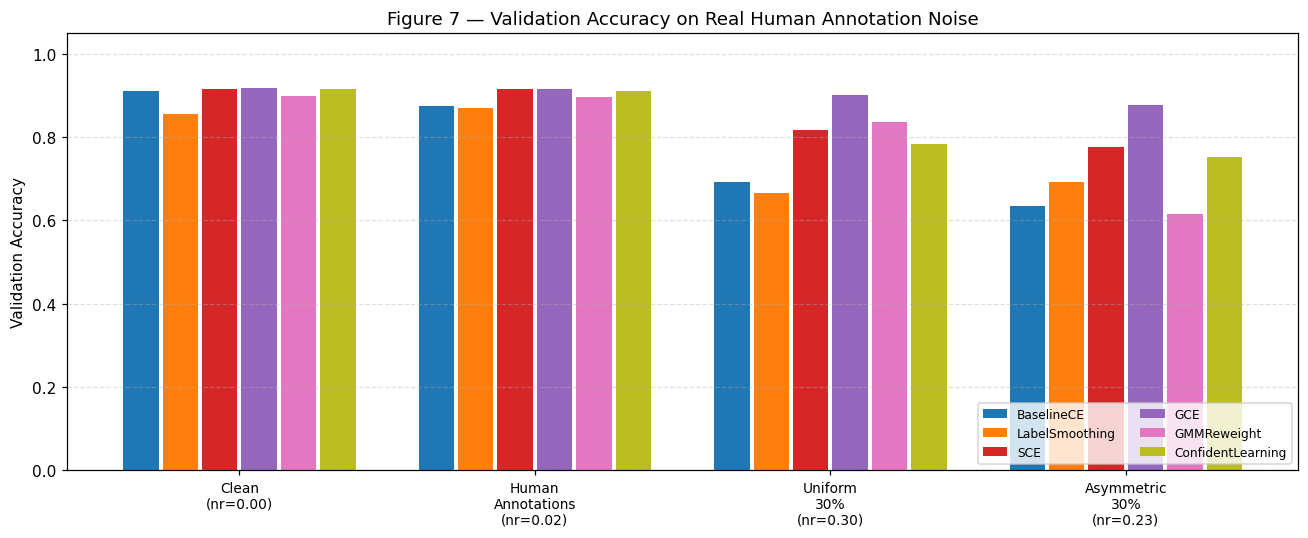

In [22]:
REAL_FILE = MYLIBS / 'results' / 'real_results.json'

if not REAL_FILE.exists():
    print("Run Phase 4B first.")
else:
    with open(REAL_FILE) as f:
        real_data = json.load(f)

    results    = real_data['results']
    noise_info = real_data['noise_rates']
    label_sets = real_data['label_sets']
    METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                    'GMMReweight', 'ConfidentLearning']
    LS_DISPLAY = {'clean': 'Clean', 'human': 'Human\nAnnotations',
                  'uniform_30': 'Uniform\n30%', 'asymmetric_30': 'Asymmetric\n30%'}

    n_groups  = len(label_sets)
    n_methods = len(METHOD_ORDER)
    bar_width = 0.8 / n_methods
    colors_bar = cm.tab10(np.linspace(0, 0.8, n_methods))

    fig, ax = plt.subplots(figsize=(max(10, n_groups * 3), 5))
    ax.set_title('Figure 7 — Validation Accuracy on Real Human Annotation Noise', fontsize=12)

    x_base = np.arange(n_groups)
    for m_i, (m_name, color) in enumerate(zip(METHOD_ORDER, colors_bar)):
        accs   = [results.get(ls, {}).get(m_name, 0.0) for ls in label_sets]
        offset = (m_i - n_methods / 2 + 0.5) * bar_width
        ax.bar(x_base + offset, accs, width=bar_width * 0.9, color=color, label=m_name)

    xlabels = []
    for ls in label_sets:
        base = LS_DISPLAY.get(ls, ls)
        nr   = noise_info.get(ls)
        xlabels.append(f"{base}\n(nr={nr:.2f})" if nr is not None else base)

    ax.set_xticks(x_base); ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.0, 1.05)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8, loc='lower right', ncol=2)
    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig7_real_data_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 8 — Annotated Subset vs Full-Training Bar Chart

Grouped bar chart comparing all three conditions (Clean full training, Human annotations full training, Annotated subset only) side by side per method. The subset bars are outlined in black to highlight the effect of training on only 433 human-annotated samples at ~14% noise.

In [ ]:
_SUBSET_FILE = MYLIBS / 'results' / 'annotated_subset_results.json'
_REAL_FILE   = MYLIBS / 'results' / 'real_results.json'

if not _SUBSET_FILE.exists() or not _REAL_FILE.exists():
    print("Run Phase 4B and 4C first.")
else:
    with open(_SUBSET_FILE) as _f: _sd = json.load(_f)
    with open(_REAL_FILE)   as _f: _rd = json.load(_f)

    _METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                     'GMMReweight', 'ConfidentLearning']
    _conditions = [
        ('Clean\n(full, nr=0.00)',                              _rd['results']['clean'], '#4878d0', 0.85),
        ('Human\n(full, nr=0.02)',                              _rd['results']['human'], '#6acc65', 0.85),
        ('Subset only\n(nr={:.2f})'.format(_sd['noise_rate']), _sd['results'],           '#d65f5f', 1.00),
    ]

    _x, _w, _n = np.arange(len(_METHOD_ORDER)), 0.22, len(_conditions)
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Figure 8 — Method Accuracy: Clean vs Human Annotations vs Annotated Subset', fontsize=12)

    for _ci, (label, res, color, alpha) in enumerate(_conditions):
        _offset  = (_ci - _n / 2 + 0.5) * _w
        _accs    = [res.get(_m, 0.0) for _m in _METHOD_ORDER]
        _is_sub  = label.startswith('Subset')
        _bars    = ax.bar(_x + _offset, _accs, width=_w * 0.92,
                          color=color, alpha=alpha, label=label,
                          edgecolor='black' if _is_sub else 'none',
                          linewidth=1.2 if _is_sub else 0)
        for _bar, _acc in zip(_bars, _accs):
            ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 0.005,
                    f'{_acc:.2f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

    ax.set_xticks(_x); ax.set_xticklabels(_METHOD_ORDER, fontsize=10)
    ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.55, 1.05)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig8_subset_bar.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 9 — Human Noise vs Equivalent Synthetic Noise

Compares subset accuracy (~14% human noise, 433 samples) against synthetic uniform noise at the two nearest rates (10% and 20%, full 3673 samples, mean over 3 seeds). Gap labels show how much the human subset result differs from the synthetic 10% baseline, separating the effect of noise type from the effect of dataset size.

In [ ]:
_SUBSET_FILE    = MYLIBS / 'results' / 'annotated_subset_results.json'
_SYNTHETIC_FILE = MYLIBS / 'results' / 'synthetic_results.json'

if not _SUBSET_FILE.exists() or not _SYNTHETIC_FILE.exists():
    print("Run Phase 4A and 4C first.")
else:
    with open(_SUBSET_FILE)    as _f: _sd  = json.load(_f)
    with open(_SYNTHETIC_FILE) as _f: _syn = json.load(_f)

    _METHOD_ORDER = ['BaselineCE', 'LabelSmoothing', 'SCE', 'GCE',
                     'GMMReweight', 'ConfidentLearning']
    _nr_human = _sd['noise_rate']
    _syn10 = {m: np.mean(_syn['uniform']['0.1'][m]) for m in _METHOD_ORDER}
    _syn20 = {m: np.mean(_syn['uniform']['0.2'][m]) for m in _METHOD_ORDER}

    _conditions = [
        ('Synthetic uniform 10%\n(full set, nr=0.10)', _syn10,          '#4878d0'),
        ('Human subset {:.0%}\n(433 samples, nr={:.2f})'.format(_nr_human, _nr_human),
                                                        _sd['results'], '#d65f5f'),
        ('Synthetic uniform 20%\n(full set, nr=0.20)', _syn20,          '#ee854a'),
    ]

    _x, _w, _n = np.arange(len(_METHOD_ORDER)), 0.25, len(_conditions)
    fig, ax = plt.subplots(figsize=(12, 5))
    fig.suptitle('Figure 9 — Human Noise vs Equivalent Synthetic Noise Rate', fontsize=12)

    for _ci, (label, res, color) in enumerate(_conditions):
        _offset = (_ci - _n / 2 + 0.5) * _w
        _accs   = [res.get(_m, 0.0) for _m in _METHOD_ORDER]
        _hatch  = '//' if 'Human' in label else ''
        ax.bar(_x + _offset, _accs, width=_w * 0.92,
               color=color, alpha=0.85, label=label, hatch=_hatch,
               edgecolor='black' if _hatch else color, linewidth=0.8)

    # Gap annotation: human subset minus synthetic 10%
    for _i, _m in enumerate(_METHOD_ORDER):
        _gap = _sd['results'].get(_m, 0) - _syn10.get(_m, 0)
        _y   = min(_sd['results'].get(_m, 0), _syn10.get(_m, 0)) - 0.032
        ax.annotate(f'{_gap:+.2f}', xy=(_i, _y), ha='center', fontsize=8,
                    color='green' if _gap >= 0 else 'red')

    ax.set_xticks(_x); ax.set_xticklabels(_METHOD_ORDER, fontsize=10)
    ax.set_ylabel('Validation Accuracy'); ax.set_ylim(0.55, 1.02)
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.legend(fontsize=9, loc='lower right')
    ax.text(0.01, 0.02, 'Gap labels: human subset minus synthetic 10%',
            transform=ax.transAxes, fontsize=8, color='gray', style='italic')
    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig9_human_vs_synthetic.png', dpi=150, bbox_inches='tight')
    plt.show()

### Figure 10 — Per-Class Annotation Error Breakdown

Left: raw error counts per class in the training split annotations. Right: flip-destination heatmap showing which class pairs confused annotators most (diagonal = correct, off-diagonal = error).

In [ ]:
from noise.human import _load_csv as _load_annotation_csv

_ANNOTATIONS_CSV = MYLIBS / 'manual_annotations.csv'

if not _ANNOTATIONS_CSV.exists() or _ANNOTATIONS_CSV.stat().st_size < 50:
    print("Run annotation tool first.")
else:
    _annotation_map = _load_annotation_csv(str(_ANNOTATIONS_CSV))
    _image_dir      = Path(str(image_paths[train_idx[0]])).parent.parent

    _cls_annotated = np.zeros(len(CLASSES), dtype=int)
    _cls_errors    = np.zeros(len(CLASSES), dtype=int)
    _flip_matrix   = np.zeros((len(CLASSES), len(CLASSES)), dtype=int)

    for _pos, _gidx in enumerate(train_idx):
        _abs = Path(str(image_paths[_gidx]))
        try:
            _rel = _abs.relative_to(_image_dir).as_posix()
        except ValueError:
            continue
        if _rel not in _annotation_map:
            continue
        _true  = train_labels[_pos]
        _human = _annotation_map[_rel]
        _cls_annotated[_true] += 1
        if _human != _true:
            _cls_errors[_true] += 1
        _flip_matrix[_true, _human] += 1

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Figure 10 — Per-Class Human Annotation Errors (training split)', fontsize=12)

    _pal = ['#4878d0', '#6acc65', '#ee854a', '#d65f5f', '#956cb4']
    _bars = axes[0].bar(CLASSES, _cls_errors, color=_pal, alpha=0.85)
    for _b, _ne, _nt in zip(_bars, _cls_errors, _cls_annotated):
        axes[0].text(_b.get_x() + _b.get_width() / 2, _b.get_height() + 0.3,
                     f'{_ne}/{_nt}', ha='center', va='bottom', fontsize=9)
    axes[0].set_title('Error count per class')
    axes[0].set_ylabel('Mislabelled samples')
    axes[0].set_ylim(0, _cls_errors.max() + 5)
    axes[0].grid(True, axis='y', linestyle='--', alpha=0.4)

    _im = axes[1].imshow(_flip_matrix, cmap='Blues')
    axes[1].set_xticks(range(len(CLASSES))); axes[1].set_yticks(range(len(CLASSES)))
    axes[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=9)
    axes[1].set_yticklabels(CLASSES, fontsize=9)
    axes[1].set_xlabel('Human label'); axes[1].set_ylabel('True label')
    axes[1].set_title('Flip pattern\n(diagonal = correct, off-diagonal = error)')
    for _i in range(len(CLASSES)):
        for _j in range(len(CLASSES)):
            _v = _flip_matrix[_i, _j]
            axes[1].text(_j, _i, str(_v), ha='center', va='center',
                         fontsize=8.5,
                         color='white' if _v > _flip_matrix.max() * 0.55 else 'black')
    plt.colorbar(_im, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(MYLIBS / 'results' / 'fig10_per_class_errors.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nPer-class error rate (training annotations only):")
    for _i, _cls in enumerate(CLASSES):
        _rate = _cls_errors[_i] / _cls_annotated[_i] if _cls_annotated[_i] else 0
        print(f"  {_cls:12s}  {_cls_errors[_i]:2d}/{_cls_annotated[_i]}  ({_rate:.1%})")

---
## Summary

All figures are saved as PNGs in `mylibs/results/`:

| File | Figure |
|---|---|
| `fig1_accuracy_curves.png` | Accuracy vs noise rate (3 noise types) |
| `fig2_loss_histogram.png` | GMM loss histograms (5 noise rates) |
| `fig3_transition_matrix.png` | CL estimated vs true transition matrix |
| `fig4_flagged_samples.png` | Image grid of samples flagged by CL |
| `fig5_calibration.png` | CL noise rate calibration scatter |
| `fig6_learning_curves.png` | Val accuracy per epoch at 40% uniform noise |
| `fig7_real_data_bar.png` | Method comparison on real human annotations (full training set) |
| `fig8_subset_bar.png` | Clean vs Human-full vs Subset-only per method |
| `fig9_human_vs_synthetic.png` | Human subset noise vs equivalent synthetic noise rates |
| `fig10_per_class_errors.png` | Per-class annotation error counts and flip-destination heatmap |

Raw results are in `mylibs/results/`:

| File | Contents |
|---|---|
| `synthetic_results.json` | Full synthetic sweep (3 noise types × 6 rates × 3 seeds × 6 methods) |
| `synthetic_aux.json` | Per-sample losses, transition matrices, epoch curves |
| `real_results.json` | Phase 4B — all methods on clean / human / uniform\_30 / asymmetric\_30 |
| `annotated_subset_results.json` | Phase 4C — all methods trained on 433 annotated samples only |